<a href="https://colab.research.google.com/github/Samruddhi-273/SOC-repo/blob/master/DataCleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Cleaning Tutorial: Titanic Dataset**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = sns.load_dataset("titanic")

In [3]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
data.size

13365

In [7]:
data_cleaned = data.copy()

In [8]:
duplicate_count = data_cleaned.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

duplicates = data_cleaned[data_cleaned.duplicated(keep=False)]
duplicates_sorted = duplicates.sort_values(by=duplicates.columns.tolist())
print(f"Dataframe Rows: {duplicates_sorted.shape[0]}")
print(f"Dataframe Columns : {duplicates_sorted.shape[1]}")

duplicates_sorted.head()

Number of duplicate rows: 107
Dataframe Rows: 160
Dataframe Columns : 15


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
64,0,1,male,NaN,0,0,27.7208,C,First,man,True,NaN,Cherbourg,no,True
295,0,1,male,NaN,0,0,27.7208,C,First,man,True,NaN,Cherbourg,no,True
144,0,2,male,18.0,0,0,11.5000,S,Second,man,True,NaN,Southampton,no,True
757,0,2,male,18.0,0,0,11.5000,S,Second,man,True,NaN,Southampton,no,True
658,0,2,male,23.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True


In [10]:
initial_size = data_cleaned.size

data_cleaned = data_cleaned.drop_duplicates()

final_size = data_cleaned.size

proportion_removed = ((initial_size - final_size) / initial_size) * 100

print(f"Proportion of Data Removed: {proportion_removed:.2f}%")

Proportion of Data Removed: 0.00%


In [11]:
missing_data = data_cleaned.isnull().sum()

In [12]:
missing_percentage = (missing_data / len(data_cleaned)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_data,
    'Row Percentage': missing_percentage
})
missing_df

,Missing Values,Row Percentage
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
age,106,13.520408
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000
embarked,2,0.255102
class,0,0.000000
who,0,0.000000


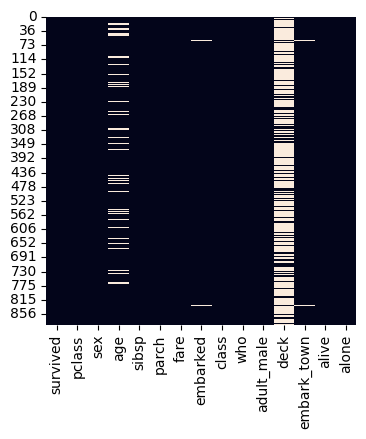

In [13]:
plt.figure(figsize=(4, 4))
sns.heatmap(data_cleaned.isnull(), cbar=False);

In [14]:
total_elements = data_cleaned.size
total_rows = data_cleaned.shape[0]
total_columns = data_cleaned.shape[1]

In [15]:
null_columns = (missing_data > 0).sum()
column_removal_proportion = (total_rows * null_columns) / total_elements * 100

null_rows = data_cleaned.isnull().any(axis=1).sum()
row_removal_proportion = (null_rows * total_columns) / total_elements * 100

print(f"Percentage of data lost by removing columns with missing values: {column_removal_proportion:.2f}%")
print(f"Percentage of data lost by removing rows with missing values: {row_removal_proportion:.2f}%")

Percentage of data lost by removing columns with missing values: 26.67%
Percentage of data lost by removing rows with missing values: 76.91%


In [16]:
data_cleaned.dropna(inplace=True)

data_cleaned = data_cleaned.dropna()

In [17]:
data_cleaned = data_cleaned.dropna(subset=['embarked', 'embark_town'])

In [18]:
data_cleaned = data_cleaned.drop(columns=['deck'])

In [19]:
data_cleaned['age'] = data_cleaned['age'].fillna(data_cleaned['age'].mean())

data_filled = data_cleaned.fillna(method='ffill')

/tmp/ipykernel_2212/976429253.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_filled = data_cleaned.fillna(method='ffill')


In [20]:
before = data.size
after = data_cleaned.size
difference = before - after
print(f"Proportion of data removed: {round((difference / before) *100, 2)}%")

data_cleaned.isnull().sum()

Proportion of data removed: 81.04%


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [21]:
data_cleaned.describe()

,survived,pclass,age,sibsp,parch,fare
count,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000
mean,0.674033,1.193370,35.687403,0.469613,0.480663,78.972883
std,0.470035,0.517644,15.691057,0.645854,0.757123,76.699584
min,0.000000,1.000000,0.920000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,24.000000,0.000000,0.000000,29.700000
50%,1.000000,1.000000,36.000000,0.000000,0.000000,57.000000
75%,1.000000,1.000000,48.000000,1.000000,1.000000,90.000000
max,1.000000,3.000000,80.000000,3.000000,4.000000,512.329200


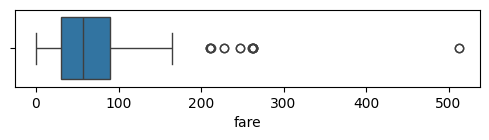

In [22]:
plt.figure(figsize=(6, 1))
sns.boxplot(x=data_cleaned['fare']);

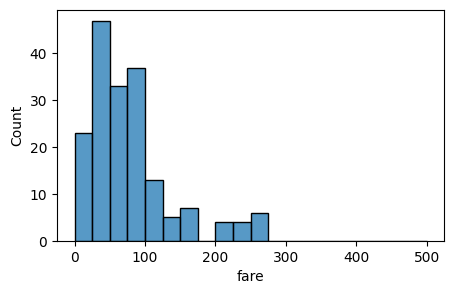

In [23]:
plt.figure(figsize=(5,3))
sns.histplot(data_cleaned['fare'], bins=range(0,513,25));

In [24]:
column_list = ['survived',
              'pclass',
              'age',
              'sibsp',
              'parch',
              'fare'
              ]

results = []

for column in column_list:
    q1 = data_cleaned[column].quantile(0.25)
    q3 = data_cleaned[column].quantile(0.75)
    iqr = q3 - q1

    standard_threshold = q3 + 1.5 * iqr
    standard_outliers = (data_cleaned[column] > standard_threshold).sum()
    proportion = (standard_outliers / len(data_cleaned)) * 100

    results.append([
        column,
        standard_outliers,
        f"{proportion:.2f}%"
    ])

outlier_df = pd.DataFrame(results, columns=[
    'Column',
    'Number of Outliers',
    'Proportion'
])

outlier_df

,Column,Number of Outliers,Proportion
0,survived,0,0.00%
1,pclass,25,13.81%
2,age,0,0.00%
3,sibsp,3,1.66%
4,parch,1,0.55%
5,fare,16,8.84%


In [25]:
q1 = data_cleaned['parch'].quantile(0.25)
q3 = data_cleaned['parch'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers_removed = data_cleaned[(data_cleaned['parch'] >= lower_bound) & (data_cleaned['parch'] <= upper_bound)]

proportion_removed = ((len(data_cleaned) - len(outliers_removed)) / len(data_cleaned)) * 100
print(f"Proportion Removed: {round(proportion_removed, 2)}%\n")

Proportion Removed: 0.55%



In [26]:
from scipy import stats

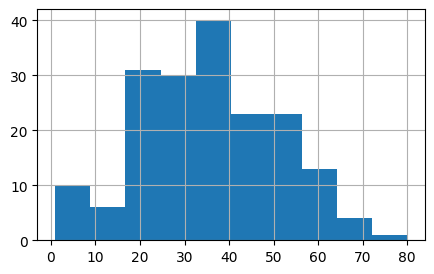

In [27]:
plt.figure(figsize=(5,3))
data_cleaned['age'].hist();

In [28]:
mean = np.mean(data_cleaned['age'])
std_dev = np.std(data_cleaned['age'])

print(f"Mean: {mean}")
print(f"Standard Deviation: {std_dev}")

Mean: 35.68740331491713
Standard Deviation: 15.647651700957056


In [30]:
lower_limit_1 = mean - std_dev
upper_limit_1 = mean + std_dev

lower_limit_2 = mean - 2 * std_dev
upper_limit_2 = mean + 2 * std_dev

lower_limit_3 = mean - 3 * std_dev
upper_limit_3 = mean + 3 * std_dev

In [31]:
within_1_std = ((data_cleaned['age'] >= lower_limit_1) & (data_cleaned['age'] <= upper_limit_1)).mean()
within_2_std = ((data_cleaned['age'] >= lower_limit_2) & (data_cleaned['age'] <= upper_limit_2)).mean()
within_3_std = ((data_cleaned['age'] >= lower_limit_3) & (data_cleaned['age'] <= upper_limit_3)).mean()

print(f"{round(within_1_std * 100, 2)}% of data falls within 1 standard deviation.")
print(f"{round(within_2_std * 100, 2)}% of data falls within 2 standard deviations.")
print(f"{round(within_3_std * 100, 2)}% of data falls within 3 standard deviations.")

67.4% of data falls within 1 standard deviation.
93.37% of data falls within 2 standard deviations.
100.0% of data falls within 3 standard deviations.


In [32]:
data_cleaned['z_score'] = stats.zscore(data_cleaned['age'], ddof=1)
sample_df = data_cleaned[['age', 'z_score']]
sample_df.head()

,age,z_score
1,38.0,0.147383
3,35.0,-0.043809
6,54.0,1.167072
10,4.0,-2.019456
11,58.0,1.421994


In [33]:
sample_df[(sample_df['z_score'] > 3) | (sample_df['z_score'] < -3)]

,age,z_score


In [34]:
outliers_removed = data_cleaned[(data_cleaned['z_score'] <= 3) & (data_cleaned['z_score'] >= -3)]

proportion_removed = ((len(data_cleaned) - len(outliers_removed)) / len(data_cleaned)) * 100
print(f"Proportion Removed: {round(proportion_removed, 2)}%\n")

Proportion Removed: 0.0%



In [35]:
data_cleaned.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [36]:
data_cleaned['embarked'] = data_cleaned['embarked'].astype('category')